(control:optimal:ref-tracking:example)=
# Example of optimal control for tracking reference input


In [18]:
#!pip install control

## Mass-damper-spring system

$$\begin{aligned}
 \begin{bmatrix} \dot{x} \\ \dot{v} \end{bmatrix} & = \begin{bmatrix} \cdot & 1 \\ - \frac{k}{m} & - \frac{c}{m} \end {bmatrix} \begin{bmatrix} x \\ v \end{bmatrix} + \begin{bmatrix} \cdot \\ 1 \end{bmatrix} u \\
 y & = \begin{bmatrix} 1 & \cdot \end{bmatrix} \begin{bmatrix} x \\ v \end{bmatrix}
\end{aligned}$$

i.e. the control $u$ is a force per unit-mass, as the second component of the state equation is nothing but the second principle of Newton's mechanics,

$$m \ddot{x} + c \dot{x} + k x = F  \ .$$

The first equation is the kinematic relation between position and velocity. The measurement output is the position $x$.

Infinite time horizon optimal problem is solved with the $\texttt{control.lqr}$ routine, see https://python-control.readthedocs.io/en/latest/generated/control.lqr.html. The continuous-time LTI system is defined as a state space system with the function $\texttt{control.ss}$, see https://python-control.readthedocs.io/en/latest/generated/control.ss.html.


## Augmented system for reference signal



### Single integral for step tracking

Let $x_{ref}$ a reference signal. An augmented system can be defined in order to used optimal control. Let

$$\begin{aligned}
 \dot{\mathbf{x}} & = \mathbf{A} \mathbf{x} + \mathbf{B} \mathbf{u} \\
      \mathbf{y}  & = \mathbf{C} \mathbf{x} + \mathbf{D} \mathbf{u}
\end{aligned}$$

the state-space representation of the plant. Let $\mathbf{y}_{ref}$ a desired output and the integral error

$$\mathbf{e}(t) := \int_{\tau=0}^{t} \left\{ \mathbf{y}(\tau) - \mathbf{y}_{ref}(\tau) \right\} d \tau \ ,$$

as a new state with dynamical equation

$$\dot{\mathbf{e}} = \mathbf{y}(t) - \mathbf{y}_{ref}(t) = \mathbf{C} \mathbf{x} + \mathbf{D} \mathbf{u} - \mathbf{y}_{ref} \ .$$

The optimal control is applied to the augmented system

$$\underbrace{\begin{bmatrix} \dot{\mathbf{x}} \\ \dot{\mathbf{e}} \end{bmatrix}}_{\dot{\mathbf{z}}} = \underbrace{\begin{bmatrix} \mathbf{A} & \cdot \\ \mathbf{C} & \cdot \end{bmatrix}}_{\hat{\mathbf{A}}} \underbrace{\begin{bmatrix} \mathbf{x} \\ \mathbf{e} \end{bmatrix}}_{\mathbf{z}} + \underbrace{\begin{bmatrix} \mathbf{B} \\ \mathbf{D} \end{bmatrix}}_{\hat{\mathbf{B}}_u} \mathbf{u} + \underbrace{\begin{bmatrix} \cdot \\ -\mathbf{I} \end{bmatrix}}_{\hat{\mathbf{B}}_{ref}} \mathbf{y}_{ref}$$

Optimal control framework provides the opitmal gain matrix $\hat{\mathbf{K}}$, so that $\mathbf{u} = - \hat{\mathbf{K}} \mathbf{z}$ and the closed loop system becomes

$$\dot{\mathbf{z}} = \left( \hat{\mathbf{A}} - \hat{\mathbf{B}}_u \hat{\mathbf{K}} \right) \mathbf{z} + \hat{\mathbf{B}}_{ref} \mathbf{y}_{ref} \ .$$

#### Optimal control design

In [19]:
import numpy as np
import control as ct
import matplotlib.pyplot as plt
import copy

#> System: Simple Mass-Spring-Damper
A = np.array([[0, 1], [-2, -0.5]])
B = np.array([[0], [1]])
C = np.array([[1, 0], [0, 1]])   # For full-state feedback, the output need to be y=x
D = np.array([[0], [0]])
sys = ct.ss(A, B, C, D)

sys_labels = {
    "state" : ["x", "v"],
    "output": ["x", "v"],
    "input" : ["f"]
}


In [32]:
#> Augmented system for reference input
# dx     = A x + B u
# dz = e =   y[0] - yref = C[0,:] x + D[0,:] u - yref
#  y     =   x
# d [ x ] = [ A      . ][ x ] + [ B     ] u + [ . ] yref
#   [ z ]   [ C[0:]  . ][ z ]   [ D[0:] ]     [-I ]

Aa = np.block([
    [     A, np.zeros((2, 1))],
    [C[0,:], np.zeros((1, 1))]
])
Ba = np.block([
    [B],
    [D[0,:]]
])
Ca = np.block([
    [C, np.zeros((2,1))]
])
Da = np.array([[0], [0]])
sys_aug = ct.ss(Aa, Ba, Ca, Da)

sys_aug_labels = copy.deepcopy(sys_labels)
sys_aug_labels["state"].append(r"$e_1 = \int_{0}^{t} y[0](\tau) - y_{ref}(\tau)$")

# LQR Weights
Q = np.diag([0., 10., 100.])
R = [[1]]

#> Calculate optimal gain
# ct.lqr() solve the infinite-horizon optimal control, using Riccati equation
# with K: state-feedback gain matrix
#      S: solution to ARE
#      E: closed-loop system eigenvalues
Ka, Sa, Ea = ct.lqr(sys_aug, Q, R)

# print("\nGain matrix\n")
# print("Ka: \n", Ka)

# print("Aa: \n", Aa)
# print("Ba: \n", Ba)

# Simulate closed-loop response with reference input
A_cl = Aa - Ba @ Ka
B_ref = np.array([[0], [0], [-1]])
C_cl = np.eye(3)
D_cl = np.zeros((3, 1))

sys_cl = ct.ss(A_cl, B_ref, C_cl, D_cl)

# print("\nClosed loop system\n")
# print(sys_cl)


#### Response

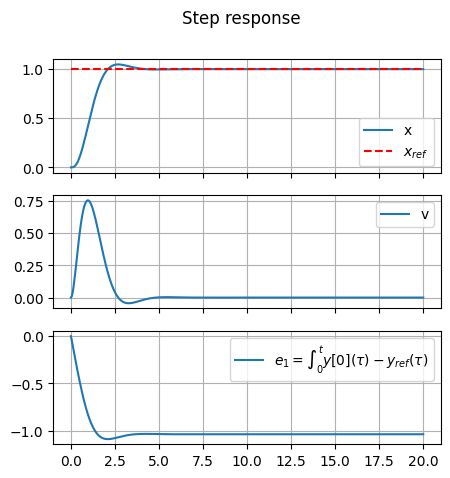

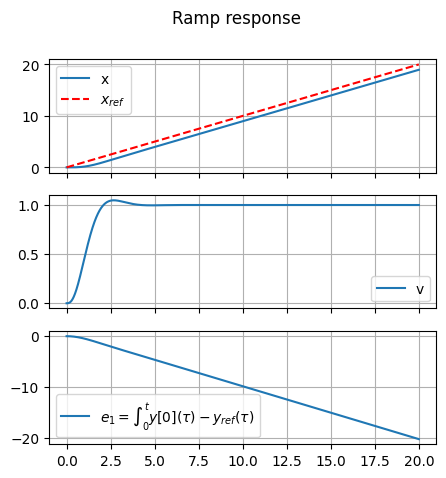

In [34]:
# This .ipynb is using an old version of control library. In latest versions of this library,
# input of response_*() functions may also be 
# - timepts (instead of T) to define final time or vector of time steps, where the input is defined
# - inputs  (instead of U) to define the input at time steps defined in timepts

n_states = np.shape(A_cl)[0]

"""
#> Impulse response
t, y = ct.impulse_response(sys_cl, T=20.)

fig, ax = plt.subplots(3,1, figsize=(5,5))
for i in range(3):
    ax[i].plot(t, y[i,0,:], label=sys_aug_labels["state"][i])
    ax[i].grid(True)
    if i < n_states-1: ax[i].set_xticklabels([])
    ax[i].legend()

fig.suptitle("Impulse response")
plt.show()
"""

#> Step response
t, y = ct.step_response(sys_cl, T=20.)

fig, ax = plt.subplots(3,1, figsize=(5,5))
for i in range(3):
    ax[i].plot(t, y[i,0,:], label=sys_aug_labels["state"][i])
    if ( i == 0 ):
        ax[i].plot(t, np.ones(len(t)), '--', color='red', label=r"$x_{ref}$")
    ax[i].grid(True)
    if i < n_states-1: ax[i].set_xticklabels([])
    ax[i].legend()

fig.suptitle("Step response")
plt.show()

#> Ramp response
tfin = 20
time_v = np.linspace(0, tfin, 100*tfin+1)
ramp_v = np.array([time_v.copy()])
t, y = ct.forced_response(sys_cl, T=time_v, U=ramp_v)

# print(np.shape(y))

fig, ax = plt.subplots(3,1, figsize=(5,5))
for i in range(3):
    ax[i].plot(t, y[i,:], label=sys_aug_labels["state"][i])
    if ( i == 0 ):
        ax[i].plot(time_v, ramp_v[0,:], '--', color='red', label=r"$x_{ref}$")
    ax[i].grid(True)
    if i < n_states-1: ax[i].set_xticklabels([])
    ax[i].legend()

fig.suptitle("Ramp response")

plt.show()

### Double integral for ramp tracking

As the error never reaches a zero value in the ramp response of the augmented system with one integral, another integral is added to the system.

Let

$$\begin{aligned}
 \dot{\mathbf{x}} & = \mathbf{A} \mathbf{x} + \mathbf{B} \mathbf{u} \\
      \mathbf{y}  & = \mathbf{C} \mathbf{x} + \mathbf{D} \mathbf{u}
\end{aligned}$$

the state-space representation of the plant. Let $\mathbf{y}_{ref}$ a desired output and the integral error

$$\mathbf{e}_1(t) := \int_{\tau=0}^{t} \left\{ \mathbf{y}(\tau) - \mathbf{y}_{ref}(\tau) \right\} d \tau \ ,$$

as a new state with dynamical equation

$$\dot{\mathbf{e}}_1 = \mathbf{y}(t) - \mathbf{y}_{ref}(t) = \mathbf{C} \mathbf{x} + \mathbf{D} \mathbf{u} - \mathbf{y}_{ref} \ .$$

The second augmenting state is defined as

$$\mathbf{e}_2(t) := \int_{\tau=0}^{t} \mathbf{e}_1(\tau) \, d\tau \ ,$$

so that the dynamical equation is

$$\dot{\mathbf{e}}_2 = \mathbf{e}_1 \ .$$

The optimal control is applied to the augmented system

$$\underbrace{\begin{bmatrix} \dot{\mathbf{x}} \\ \dot{\mathbf{e}}_1 \\ \dot{\mathbf{e}}_2 \end{bmatrix}}_{\dot{\mathbf{z}}} = \underbrace{\begin{bmatrix} \mathbf{A} & \cdot & \cdot \\ \mathbf{C} & \cdot & \cdot \\ \cdot & \mathbf{I} & \cdot \end{bmatrix}}_{\hat{\mathbf{A}}} \underbrace{\begin{bmatrix} \mathbf{x} \\ \mathbf{e}_1 \\ \mathbf{e}_2 \end{bmatrix}}_{\mathbf{z}} + \underbrace{\begin{bmatrix} \mathbf{B} \\ \mathbf{D} \\ \cdot \end{bmatrix}}_{\hat{\mathbf{B}}_u} \mathbf{u} + \underbrace{\begin{bmatrix} \cdot \\ -\mathbf{I} \\ \cdot \end{bmatrix}}_{\hat{\mathbf{B}}_{ref}} \mathbf{y}_{ref}$$

Optimal control framework provides the opitmal gain matrix $\hat{\mathbf{K}}$, so that $\mathbf{u} = - \hat{\mathbf{K}} \mathbf{z}$.

#### Optimal control design

In [22]:
#> Augmented system for reference input
# ...

Aaa = np.block([
    [     A, np.zeros((2, 2))],
    [C[0,:], np.zeros((1, 2))],
    [np.zeros((1,2)), np.ones((1,1)), np.zeros((1,1)) ]
])
Baa = np.block([
    [B],
    [D[0,:]],
    [0]
])
Caa = np.block([
    [C, np.zeros((2,2))]
])
Daa = np.array([[0], [0]])
sys_aug = ct.ss(Aaa, Baa, Caa, Daa)

sys_aug_labels = copy.deepcopy(sys_labels)
sys_aug_labels["state"].append(r"$e_1 = \int_{0}^{t} y[0](\tau) - y_{ref}(\tau)$")
sys_aug_labels["state"].append(r"$e_2 = \int_{0}^{t} e_1(\tau)$")

# LQR Weights
Q = np.diag([0., 10., 100., 100.])
R = [[1]]

#> Calculate optimal gain
# ct.lqr() solve the infinite-horizon optimal control, using Riccati equation
# with K: state-feedback gain matrix
#      S: solution to ARE
#      E: closed-loop system eigenvalues
Kaa, Saa, Eaa = ct.lqr(sys_aug, Q, R)

# print("\nGain matrix\n")
# print("Ka: \n", Ka)

# print("Aa: \n", Aa)
# print("Ba: \n", Ba)

# Simulate closed-loop response with reference input
A_cl = Aaa - Baa @ Kaa
B_ref = np.array([[0], [0], [-1], [0]])
C_cl = np.eye(4)
D_cl = np.zeros((4, 1))

sys_cl = ct.ss(A_cl, B_ref, C_cl, D_cl)

# print("\nClosed loop system\n")
# print(sys_cl)


In [23]:
# print(sys_labels)
# print(sys_aug_labels)

#### Response

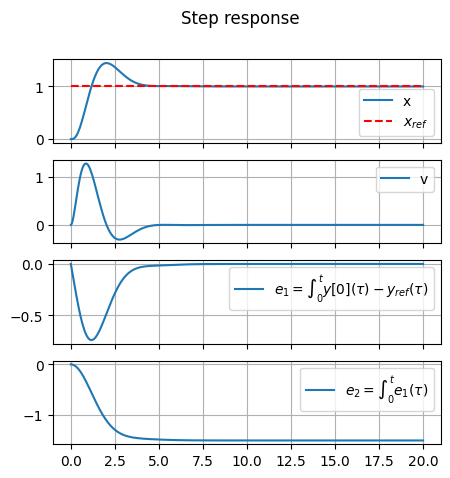

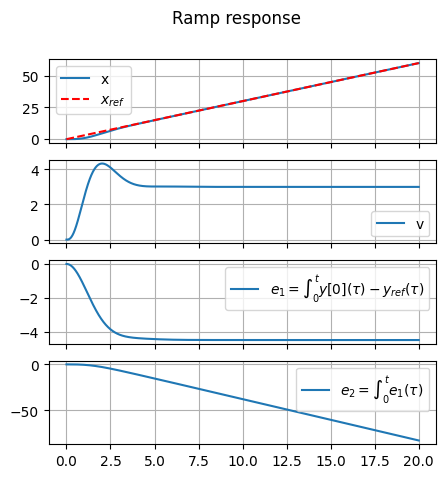

In [28]:
n_states = np.shape(A_cl)[0]

"""
#> Impulse response
t, y = ct.impulse_response(sys_cl, T=20.)

fig, ax = plt.subplots(n_states,1, figsize=(5,5))
for i in range(n_states):
    ax[i].plot(t, y[i,0,:], label=sys_aug_labels["state"][i])
    ax[i].grid(True)
    if i < n_states-1: ax[i].set_xticklabels([])
    ax[i].legend()

fig.suptitle("Impulse response")
plt.show()
"""

#> Step response
t, y = ct.step_response(sys_cl, T=20.)

fig, ax = plt.subplots(n_states,1, figsize=(5,5))
for i in range(n_states):
    ax[i].plot(t, y[i,0,:], label=sys_aug_labels["state"][i])
    if ( i == 0 ):
        ax[i].plot(t, np.ones(len(t)), '--', color='red', label=r"$x_{ref}$")
    ax[i].grid(True)
    if i < n_states-1: ax[i].set_xticklabels([])
    ax[i].legend()

fig.suptitle("Step response")
plt.show()


#> Ramp response
ramp_slope = 3.
tfin = 20
time_v = np.linspace(0, tfin, 100*tfin+1)
ramp_v = ramp_slope * np.array([time_v.copy()])
t, y = ct.forced_response(sys_cl, T=time_v, U=ramp_v)

# print(np.shape(y))

fig, ax = plt.subplots(n_states,1, figsize=(5,5))
for i in range(n_states):
    ax[i].plot(t, y[i,:], label=sys_aug_labels["state"][i])
    if ( i == 0 ):
        ax[i].plot(time_v, ramp_v[0,:], '--', color='red', label=r"$x_{ref}$")
    ax[i].grid(True)
    if i < n_states-1: ax[i].set_xticklabels([])
    ax[i].legend()

fig.suptitle("Ramp response")
plt.show()

In [26]:
#> Steady state as a consequence of steady input
# (A-Bu K)*z + Bref * yref = 0
yref = np.array([[1.]])
z = np.linalg.solve(A_cl, -B_ref @ yref)

# print(Aaa)
# print(Baa)
# print(Kaa)
# print(Baa @ Kaa)
print("A_cl\n", A_cl)
print("B_ref\n", B_ref)

#> Steady state response
print(f"Steady-state response:\n{z}")

A_cl
 [[  0.           1.           0.           0.        ]
 [-14.99029725  -6.01918553 -19.99514804 -10.        ]
 [  1.           0.           0.           0.        ]
 [  0.           0.           1.           0.        ]]
B_ref
 [[ 0]
 [ 0]
 [-1]
 [ 0]]
Steady-state response:
[[ 1.        ]
 [ 0.        ]
 [-0.        ]
 [-1.49902973]]
